In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
pd.set_option("display.float_format","{:,.2f}".format)


In [2]:
base_dir = Path.cwd()
print(base_dir)
df = pd.read_parquet(f'{base_dir}/files/sales.parquet')

c:\Users\practicanteit3\OneDrive - TRONEX S.A\Documentos\Proyectos\Market_Basket_Analysis


In [3]:
# setting the RFM to my clients
clientes = df.groupby('cliente').agg(
    montoventapesos = ('montoventapesos','sum'),
    frecuencia = ('factura', 'nunique'),
    recencia = ('fechafactura',lambda x: (pd.Timestamp.now()-x.max()).days)
).reset_index()


# First sight to the distribution of my data

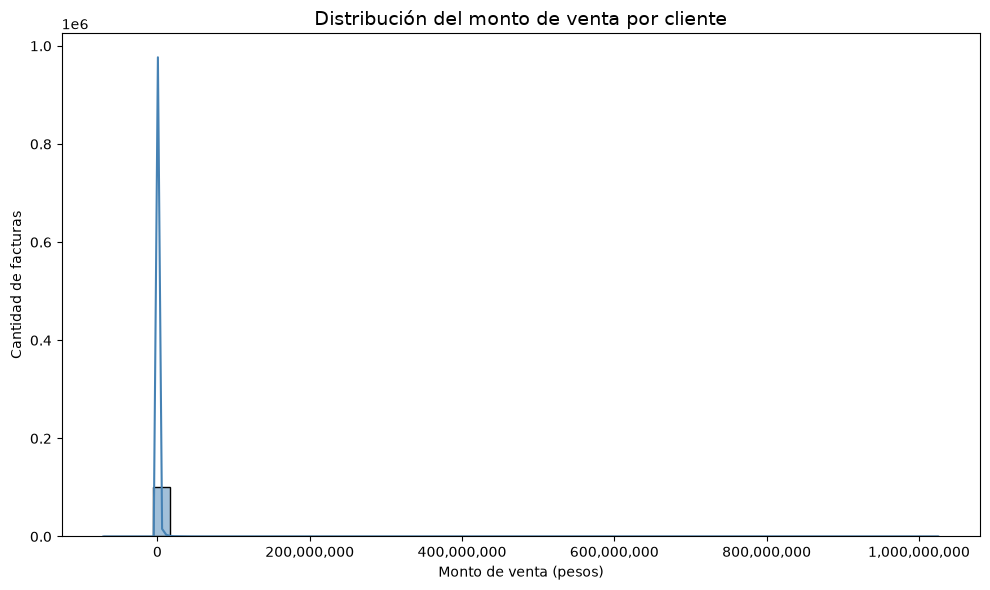

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=clientes,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=ax
)
ax.set_title('Distribución del monto de venta por cliente', fontsize=14)
ax.set_xlabel('Monto de venta (pesos)')
ax.set_ylabel('Cantidad de facturas')
#ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

> ***The data is skewed to the the right, so in this ocassion we are going to apply a log scale (I have done some researchs to look for it)***

In [5]:
devoluciones = clientes[clientes['montoventapesos']<=0]
clientes_positivos = clientes[clientes['montoventapesos']>0]


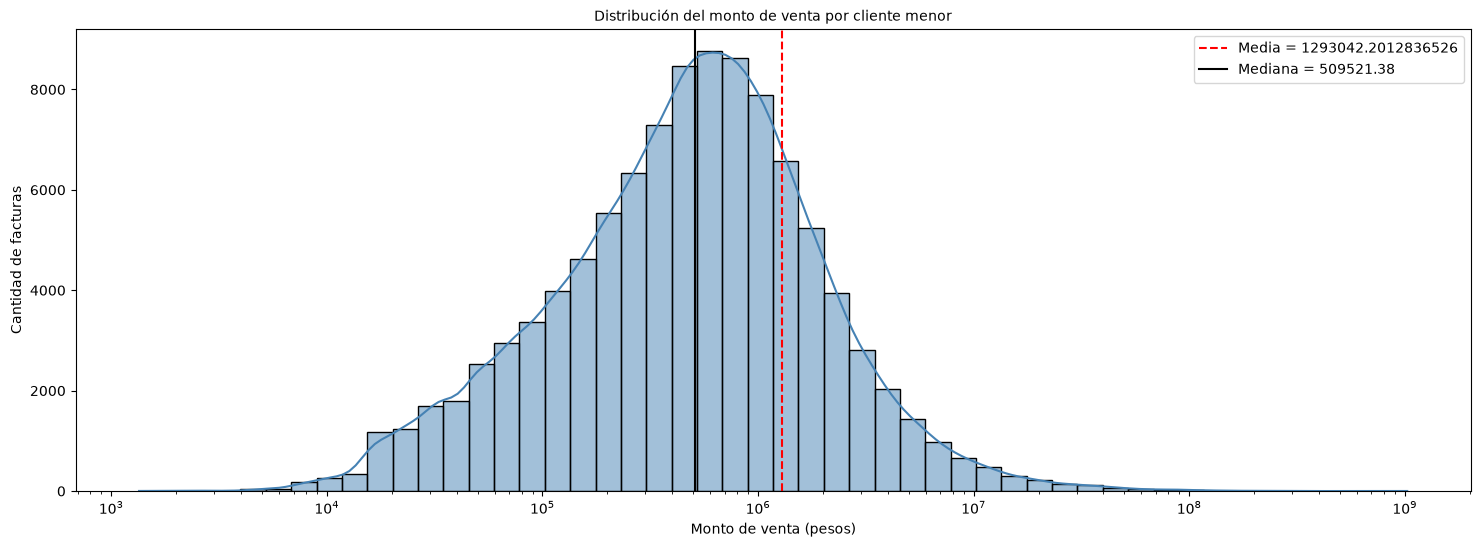

In [6]:
fig, axes = plt.subplots(figsize=(18, 6))
sns.histplot(
    data=clientes_positivos,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=axes,
    log_scale=True
)

media = clientes_positivos['montoventapesos'].mean()
median = clientes_positivos['montoventapesos'].median() 
axes.set_title('Distribución del monto de venta por cliente menor', fontsize=10)
axes.set_xlabel('Monto de venta (pesos)')
axes.set_ylabel('Cantidad de facturas')
axes.axvline(media,label=f'Media = {media}', color= 'red',linestyle='--')
axes.axvline(median,label=f'Mediana = {median}', color= 'black',linestyle='-')
#axes[0].ticklabel_format(style='plain', axis='x')
#axes.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes.legend()

# **Machine Learning**
---

## Escalar los datos

In [7]:
from sklearn.preprocessing import QuantileTransformer

variables = ['frecuencia','recencia','montoventapesos']
x = clientes_positivos[variables].values
x_scaled = QuantileTransformer(output_distribution='normal', random_state=42).fit_transform(x)

x_scaled

 


array([[ 0.21620388, -0.300542  , -0.43612375],
       [-1.2127505 , -1.1595152 , -0.56194709],
       [-0.96942671,  1.08476239, -1.33905371],
       ...,
       [ 2.07444461,  0.1625524 ,  2.70727852],
       [ 1.99497097, -1.68967008,  2.57884854],
       [ 1.45327957, -0.48083942,  1.547965  ]], shape=(102243, 3))

> Take into account the a ***log10*** for 0 y ***-inf*** so it gives and error

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

clientes_positivos['pca1'] = x_pca[:,0]
clientes_positivos['pca2'] = x_pca[:,1]


pd.DataFrame(
    data=pca.components_,
    columns=variables,
    index=['PCA1','PCA2']
)




,frecuencia,recencia,montoventapesos
PCA1,0.81,-0.41,0.42
PCA2,0.40,0.91,0.11


<Axes: xlabel='pca1', ylabel='pca2'>

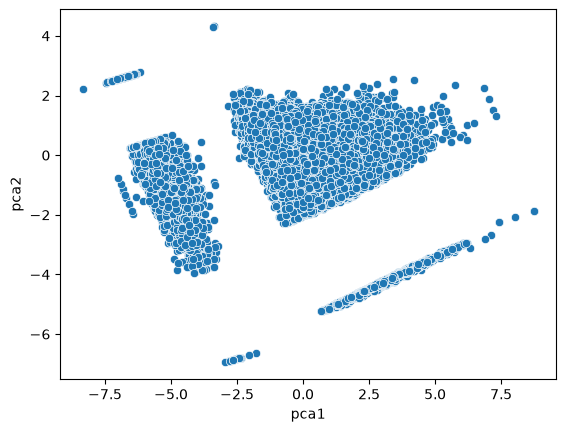

In [9]:
plt.Figure(figsize=(10,14))
sns.scatterplot(
    data=clientes_positivos,
    x=clientes_positivos['pca1'],
    y=clientes_positivos['pca2']
)

In [10]:
clientes_positivos

,cliente,montoventapesos,frecuencia,recencia,pca1,pca2
0,1000000422,"270,879.98",15,34,0.31,-0.07
1,10000008,"223,311.98",2,13,-0.55,-1.44
2,1000002095,"57,641.61",3,439,-1.60,0.61
3,1000005315,"489,502.39",16,32,0.57,-0.05
4,1000005684,"27,395.00",1,460,-5.22,-1.13
...,...,...,...,...,...,...
102310,999371,"1,640,421.70",36,25,2.30,0.42
102311,9994156,"1,134,201.23",17,73,0.67,0.60
102312,9994575,"28,643,316.72",40,66,2.95,1.44
102313,9994913,"20,855,275.80",39,10,3.59,-0.28


## ***Clustering***

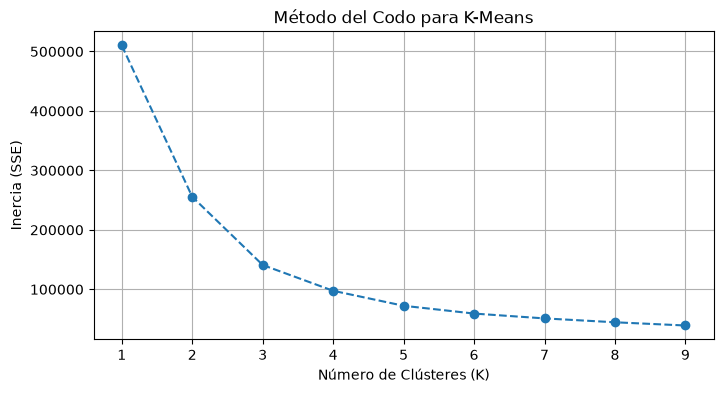

In [11]:
from sklearn.cluster import KMeans

inertia = []
rango = range(1,10)

valores = clientes_positivos[['pca1','pca2']].values
for i in rango:
    k_means = KMeans(n_clusters=i,random_state=42, n_init=10)
    k_means.fit(valores)
    inertia.append(k_means.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (SSE)')
plt.title('Método del Codo para K-Means')
plt.grid(True)
plt.show()


> Para este tema use un **K_optimo = 3**

In [12]:
K_means= KMeans(n_clusters=3,random_state=42, n_init=100).fit(clientes_positivos[['pca1','pca2']])

datos = K_means.transform(valores)
print(K_means.cluster_centers_)
clientes_positivos['cluster'] = K_means.labels_

[[-0.5404922   0.38527323]
 [ 1.58362694 -0.23821922]
 [-5.19181513 -1.02567369]]


c:\Users\practicanteit3\OneDrive - TRONEX S.A\Documentos\Proyectos\Market_Basket_Analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


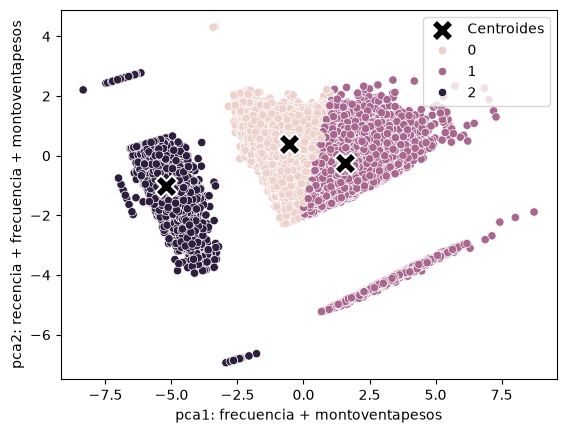

In [13]:
centroides = K_means.cluster_centers_

plt.Figure(figsize=(10,14))

centroides_x = centroides[:, 0]  # Primera columna (Eje X)
centroides_y = centroides[:, 1]  # Segunda columna (Eje Y)

# 3. Superponer los centroides sobre el gráfico
plt.scatter(
    centroides_x,
    centroides_y,
    color="black",  # Color contrastante
    s=250,  # Tamaño grande para destacar
    marker="X",  # Forma de 'X' o '*' para ver claramente el centro
    edgecolor="white",  # Borde blanco alrededor del marcador
    linewidth=1.5,
    label="Centroides",
    zorder=10,  # Mantiene los centroides al frente
)
sns.scatterplot(
    data=clientes_positivos,
    x='pca1',
    y='pca2',
    hue= 'cluster'
)

plt.xlabel('pca1: frecuencia + montoventapesos')
plt.ylabel('pca2: recencia + frecuencia + montoventapesos')
plt.legend(loc = 'upper right')


### Mezclar los clusters con su respectivo cliente

In [17]:
df_clientes = pd.merge(clientes_positivos[['cliente','cluster']],df, left_on='cliente', right_on='cliente', how='inner')

In [31]:
df_clientes.columns

Index(['cliente', 'cluster', 'factura', 'nombrecliente', 'fechafactura',
       'cantxunmedida', 'almacen', 'referencia', 'nombrereferencia',
       'cantidad', 'preciounitario', 'costounitario', 'montoventapesos',
       'costoventapesos', 'unidadnegocios', 'centrocostos', 'troevendedor',
       'troenombrevendedor', 'grouptat', 'lineatat', 'tro_e_marca', 'ruta',
       'porcentajedescuento', 'valordescuento', 'margenpesos',
       'porcentajemargen', 'zona_pais', 'zona_pais_gastos', 'canal', 'zona',
       'ciclo', 'obsequio'],
      dtype='str')

In [28]:
df_clientes.referencia.nunique()

494

In [32]:
clientes_positivos

,cliente,montoventapesos,frecuencia,recencia,pca1,pca2,cluster
0,1000000422,"270,879.98",15,34,0.31,-0.07,0
1,10000008,"223,311.98",2,13,-0.55,-1.44,0
2,1000002095,"57,641.61",3,439,-1.60,0.61,0
3,1000005315,"489,502.39",16,32,0.57,-0.05,1
4,1000005684,"27,395.00",1,460,-5.22,-1.13,2
...,...,...,...,...,...,...,...
102310,999371,"1,640,421.70",36,25,2.30,0.42,1
102311,9994156,"1,134,201.23",17,73,0.67,0.60,0
102312,9994575,"28,643,316.72",40,66,2.95,1.44,1
102313,9994913,"20,855,275.80",39,10,3.59,-0.28,1


In [50]:
values=  df_clientes.groupby('cluster').agg(
    clientes = ('cliente','nunique'),
    venta_promedio = ('montoventapesos','mean'),
    referencias_unicas = ('referencia','nunique')
).reset_index()

recencia_cluster = clientes_positivos.groupby('cluster').agg({
    'recencia':'mean',
    'frecuencia':'mean'
}).reset_index()

values = values.merge(recencia_cluster,on='cluster', how='inner')
values

,cluster,clientes,venta_promedio,referencias_unicas,recencia,frecuencia
0,0,49649,"25,917.78",460,226.92,7.98
1,1,44248,"40,199.68",479,29.47,23.83
2,2,8346,"33,889.80",344,475.89,1.00


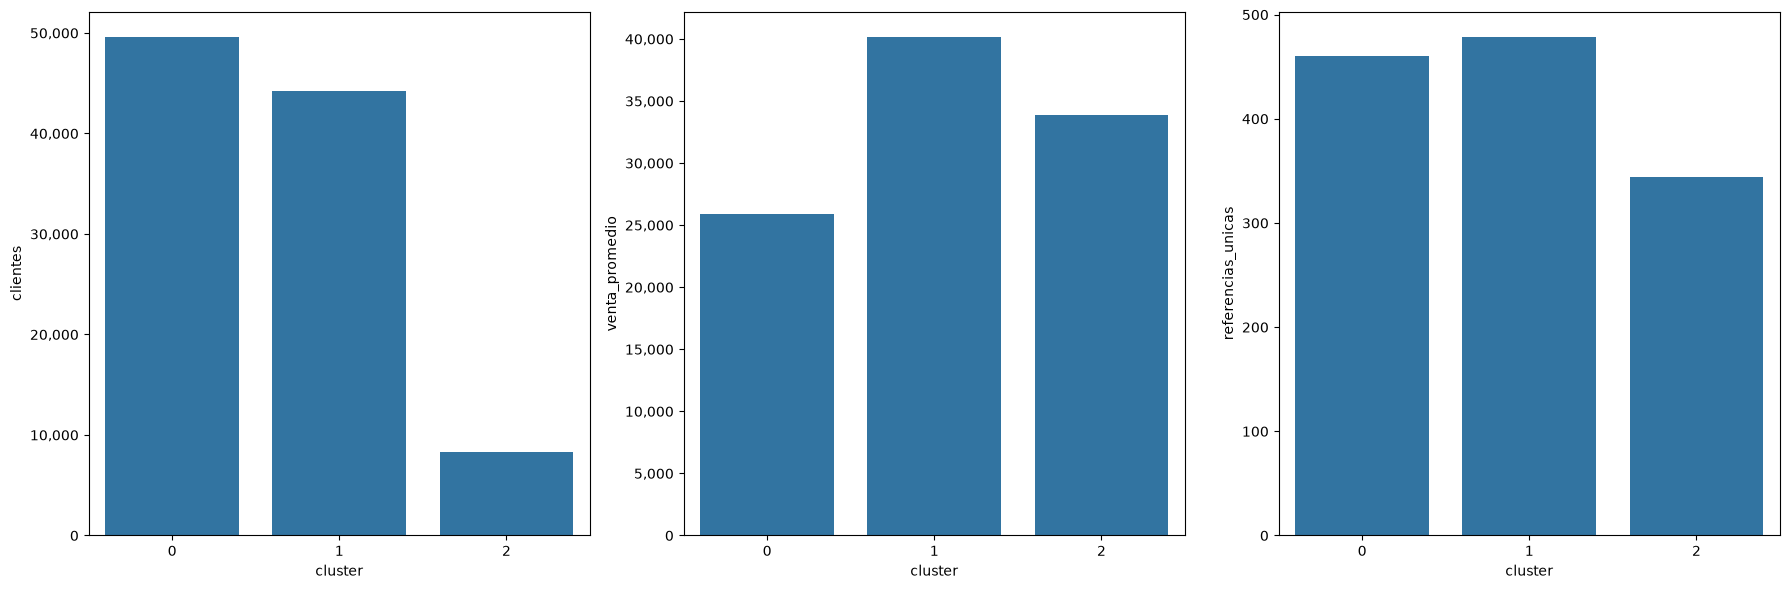

In [54]:
import matplotlib.ticker as ticker
fig, axes=plt.subplots(nrows=1, ncols=3, figsize = (18,6))


sns.barplot(
    data=values,
    x='cluster',
    y= 'clientes',
    ax=axes[0]
)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

sns.barplot(
    data=values,
    x='cluster',
    y= 'venta_promedio',
    ax=axes[1]
)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

sns.barplot(
    data=values,
    x='cluster',
    y= 'referencias_unicas',
    ax=axes[2]
)
axes[2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### Análisis Visual de los Clústeres

A continuación, realizamos un análisis detallado de las dimensiones RFM (Recencia, Frecuencia y Monto) para cada uno de los clústeres identificados, permitiéndonos caracterizar el comportamiento de cada grupo de clientes.

C:\Users\practicanteit3\AppData\Local\Temp\ipykernel_6620\4053298829.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\practicanteit3\AppData\Local\Temp\ipykernel_6620\4053298829.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\practicanteit3\AppData\Local\Temp\ipykernel_6620\4053298829.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


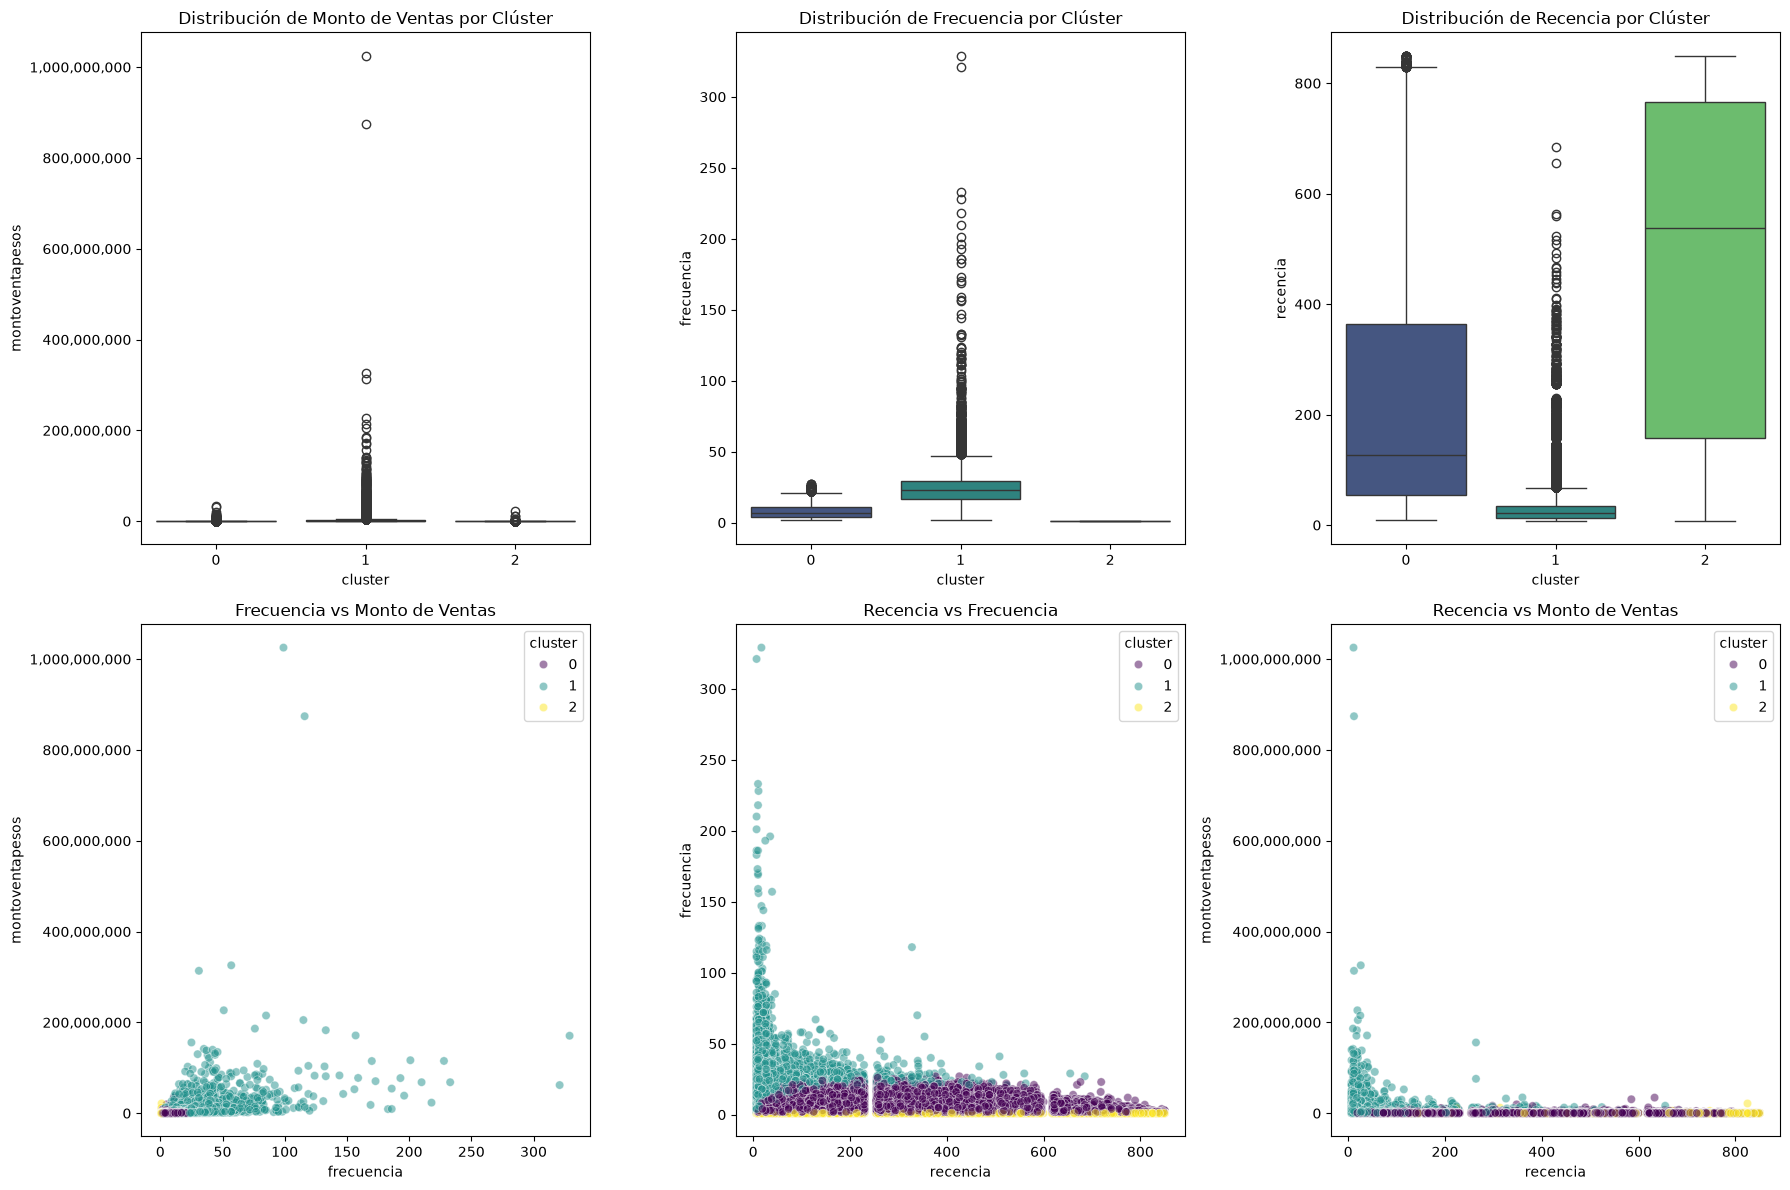

In [53]:
import matplotlib.ticker as ticker

# Crear una figura con múltiples subplots para analizar las dimensiones RFM por clúster
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))

# 1. Boxplot de Monto de Ventas por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='montoventapesos', 
    ax=axes[0, 0], 
    palette='viridis'
)
axes[0, 0].set_title('Distribución de Monto de Ventas por Clúster')
axes[0, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

# 2. Boxplot de Frecuencia por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='frecuencia', 
    ax=axes[0, 1], 
    palette='viridis'
)
axes[0, 1].set_title('Distribución de Frecuencia por Clúster')

# 3. Boxplot de Recencia por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='recencia', 
    ax=axes[0, 2], 
    palette='viridis'
)
axes[0, 2].set_title('Distribución de Recencia por Clúster')

# 4. Scatter Plot: Frecuencia vs Monto de Ventas
sns.scatterplot(
    data=clientes_positivos, 
    x='frecuencia', 
    y='montoventapesos', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 0], 
    alpha=0.5
)
axes[1, 0].set_title('Frecuencia vs Monto de Ventas')
axes[1, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

# 5. Scatter Plot: Recencia vs Frecuencia
sns.scatterplot(
    data=clientes_positivos, 
    x='recencia', 
    y='frecuencia', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 1], 
    alpha=0.5
)
axes[1, 1].set_title('Recencia vs Frecuencia')

# 6. Scatter Plot: Recencia vs Monto de Ventas
sns.scatterplot(
    data=clientes_positivos, 
    x='recencia', 
    y='montoventapesos', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 2], 
    alpha=0.5
)
axes[1, 2].set_title('Recencia vs Monto de Ventas')
axes[1, 2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.tight_layout()
plt.show()